<a href="https://colab.research.google.com/github/dacdemon/ITD/blob/main/Practica_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 3: Diagnóstico y Saneamiento de datos de pozos petroleros.
Alumnos: Damián Coria, Valentina Gomez

Comisión: 2

In [319]:
# Diagnóstico Inicial y Saneamiento técnico

# Importamos pandas y matplot

import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el archivo csv desde un repositorio web

url = "https://raw.githubusercontent.com/dacdemon/ITD/refs/heads/main/practica_3.csv"
df = pd.read_csv(url)

In [320]:
# Se busca el volumen de datos original
dimensiones = df.shape
print("Dimensiones del dataset:")
print(dimensiones[0] ,"Filas")
print(dimensiones[1], "columnas")
print()
print("Tipos de datos:")
print(df.dtypes)

Dimensiones del dataset:
3000 Filas
7 columnas

Tipos de datos:
Datetime                 object
ID_Pozo                  object
Temp_Fluido_C            object
Presion_Succion_psi     float64
Presion_Descarga_psi    float64
Caudal_BPD              float64
Vibracion_mm_s          float64
dtype: object


In [321]:
# Detección de Anomalías y conteo de fallas:
# Contar los valores faltantes de cada columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           0
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


In [322]:
# Buscar duplicados:
cantidad_duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:")
print(cantidad_duplicados)

Cantidad de registros duplicados:
0


In [323]:
# Ajuste de Formatos: Datetime y Temp_Fluido_C aparecen como texto

df["Datetime"] = pd.to_datetime(df["Datetime"])
df["Temp_Fluido_C"] = pd.to_numeric(df["Temp_Fluido_C"], errors="coerce")

# Mostrar los tipos de datos nuevamente
print("Tipos de datos después de la conversión:")
tiempo = df["Datetime"].dtype
temp = df["Temp_Fluido_C"].dtypes
print("El formato de la columna Datetime es: ", tiempo)
print("El formato de la columna Temp_Fluido_C es: ", temp)
# Comprobar nuevamente valores faltantes tras la conversión
print("Valores faltantes después de la conversión:")
print(df.isnull().sum())



Tipos de datos después de la conversión:
El formato de la columna Datetime es:  datetime64[ns]
El formato de la columna Temp_Fluido_C es:  float64
Valores faltantes después de la conversión:
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           1
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


#Registros faltantes: ¿Qué hacemos en ese caso? consideremos usar la media o la mediana?
En caso de registros faltantes lo remplazaremos con la mediana ya que no lo afectan valores extremos.

In [324]:
# Se detecto un valor faltante y se remplaza por la mediana

mediana_temp = df["Temp_Fluido_C"].median()
df["Temp_Fluido_C"] = df["Temp_Fluido_C"].fillna(mediana_temp)
print("La mediana de los valores de temperatura es", round(mediana_temp,2))
print("Se reemplaza el valor faltante y volvemos a verificar")
print(df.isnull().sum())


La mediana de los valores de temperatura es 85.0
Se reemplaza el valor faltante y volvemos a verificar
Datetime                0
ID_Pozo                 0
Temp_Fluido_C           0
Presion_Succion_psi     0
Presion_Descarga_psi    0
Caudal_BPD              0
Vibracion_mm_s          0
dtype: int64


# Outliers (seguimos con la limpieza)

In [325]:
# Primero vamos a mirar los valores mínimos y máximos.
print("Estadísticas descriptivas:")
print(df.describe())

Estadísticas descriptivas:
                            Datetime  Temp_Fluido_C  Presion_Succion_psi  \
count                           3000    3000.000000          3000.000000   
mean   2026-03-12 11:15:00.000000256      85.039633            50.335726   
min              2026-03-09 00:00:00      78.585905            23.074473   
25%              2026-03-10 17:37:30      83.704779            48.949540   
50%              2026-03-12 11:15:00      84.997415            50.003883   
75%              2026-03-14 04:52:30      86.328089            51.009209   
max              2026-03-15 22:30:00      91.523230            94.937982   
std                              NaN       1.982964             5.842141   

       Presion_Descarga_psi   Caudal_BPD  Vibracion_mm_s  
count           3000.000000  3000.000000     3000.000000  
mean             445.576920   117.684097        1.616954  
min              214.965972    75.383041        0.737939  
25%              440.307535   117.332168        1.36

#Diagnóstico: Se detecto un maximo fuera de rango, 9999 psi de Presion de descarga. se procede a su reemplazo

In [326]:
# Vemos la fila problematica

presion_anormal = df[df["Presion_Descarga_psi"] == 9999]
fila_anormal = presion_anormal.index[0]
print("Registro con presión de descarga igual a 9999 psi:")
print(presion_anormal)
print("La fila con el valor anormal es la numero", fila_anormal)

# Calculamos la mediana y reemplazamos

mediana_presion = df["Presion_Descarga_psi"].median()

df["Presion_Descarga_psi"] = df["Presion_Descarga_psi"].replace(9999, mediana_presion)

print("La mediana de los valores de presion es", round(mediana_presion,2))
print("Se reemplaza el valor de 9999 psi por su mediana y lo verificamos:")
print(df.loc[50])


Registro con presión de descarga igual a 9999 psi:
              Datetime ID_Pozo  Temp_Fluido_C  Presion_Succion_psi  \
50 2026-03-09 02:40:00    P-03      81.736616            69.551407   

    Presion_Descarga_psi  Caudal_BPD  Vibracion_mm_s  
50                9999.0  116.670936        1.532595  
La fila con el valor anormal es la numero 50
La mediana de los valores de presion es 449.13
Se reemplaza el valor de 9999 psi por su mediana y lo verificamos:
Datetime                2026-03-09 02:40:00
ID_Pozo                                P-03
Temp_Fluido_C                     81.736616
Presion_Succion_psi               69.551407
Presion_Descarga_psi             449.130733
Caudal_BPD                       116.670936
Vibracion_mm_s                     1.532595
Name: 50, dtype: object


In [327]:
# Se realiza una copia para trabajar con un dataset limpio.

df_limpio = df.copy()

print("Se creó el DataFrame df_limpio para trabajar con los datos.")

Se creó el DataFrame df_limpio para trabajar con los datos.


# Con el valor anormal corregido, se crea una copia limpia para continuar con el análisis. Ya que debemos crear 15 bloxplot y sus respectivos histogramas, nos pareció mas prolijo crear una función que nos entregue un bloxplot y un histograma a la ves y en un markdown realizar una conclusión del mismo.

In [328]:
# Armamos la funcion
def analizar_variable(df_limpio, pozo, columna, nombre):

    # Seleccionamos los datos del pozo y de la variable
    datos = df_limpio[df_limpio["ID_Pozo"] == pozo][columna]

    # Boxplot

    plt.figure(figsize=(12, 5))

    plt.boxplot(datos,
                vert=False,
                patch_artist=True,
                boxprops=dict(facecolor='#D6EAF8', color='blue', linewidth=2),
                medianprops=dict(color='red', linewidth=3))

    plt.title("Boxplot de " + nombre + " - Pozo " + pozo, fontsize=15)
    plt.xlabel(nombre, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Histograma

    plt.figure(figsize=(12, 5))
    plt.hist(datos, bins=25, edgecolor="black")
    plt.title("Histograma de " + nombre + " - Pozo " + pozo, fontsize=15)
    plt.xlabel(nombre, fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

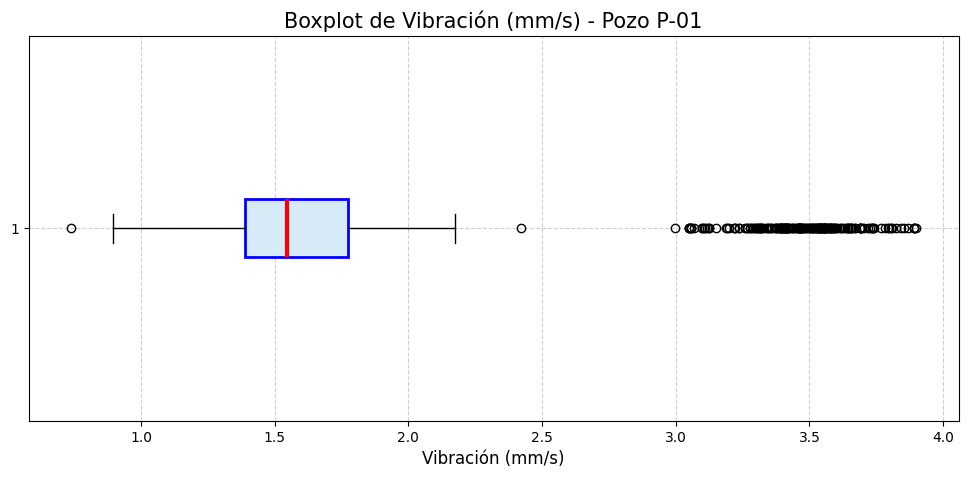

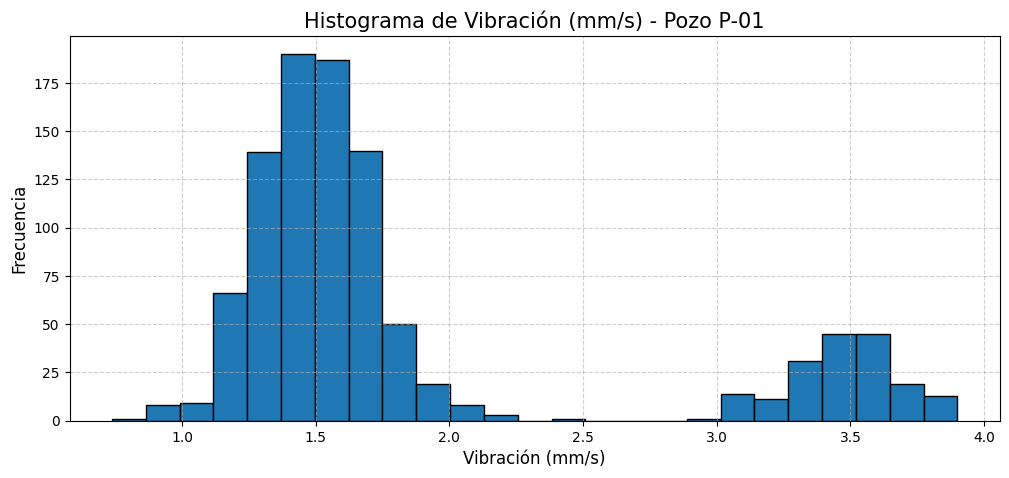

In [329]:
# Analisamos Vibración Pozo 1
analizar_variable(df_limpio, "P-01", "Vibracion_mm_s", "Vibración (mm/s)")

# Analisamos Vibración Pozo 1

El Boxplot muestra una cantidad importante de valores atípicos de vibración por encima de 3,0 mm/s. El histograma confirma que estos valores no son casos aislados, sino que forman un segundo grupo de mediciones entre aproximadamente 3,0 y 3,9 mm/s. Esto representa una posible señal de funcionamiento anormal durante un período de la operación.
# ¡Se Requiere inspección física inmediata!

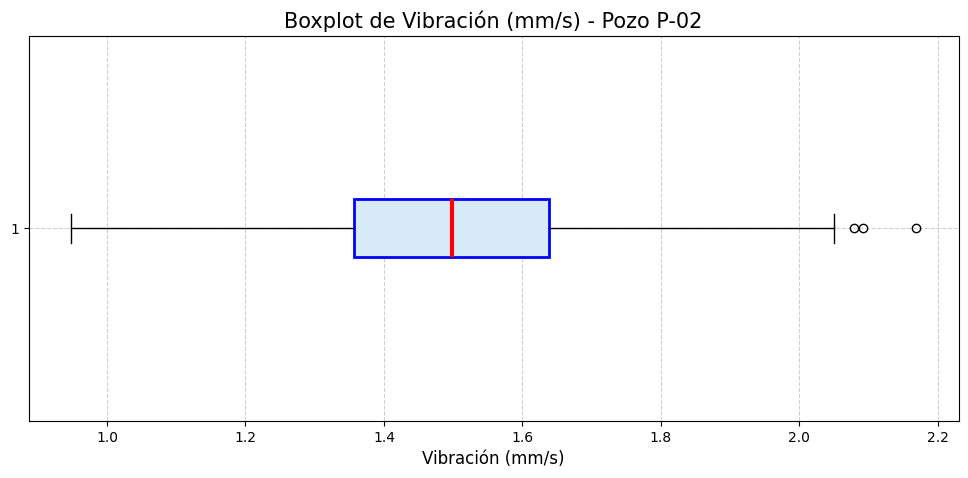

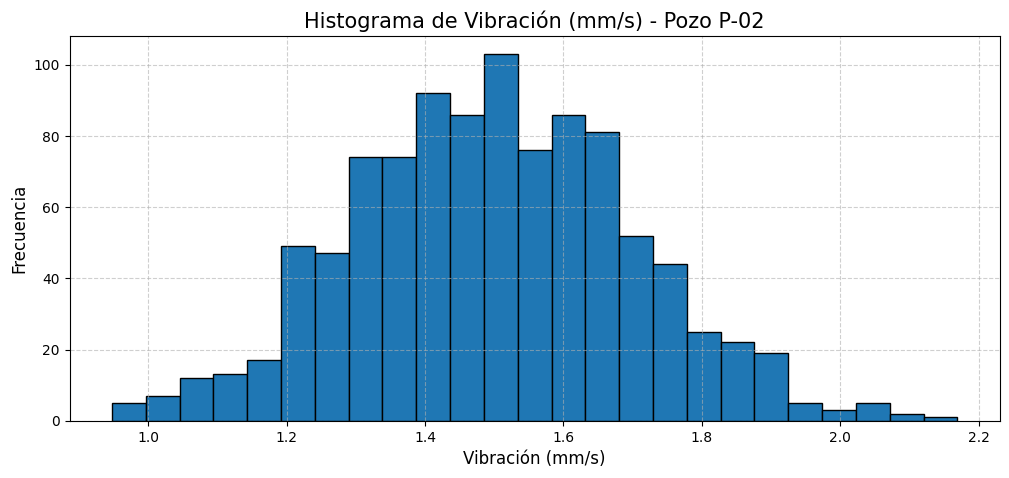

In [330]:
# Analisamos Vibración Pozo 2
analizar_variable(df_limpio, "P-02", "Vibracion_mm_s", "Vibración (mm/s)")

# Analisamos Vibración Pozo 2

El Boxplot muestra pocos valores atípicos de vibración por encima de 2,0 mm/s. El histograma presenta una distribución concentrada principalmente alrededor de 1,5 mm/s.
# No se observa señales de alarma.

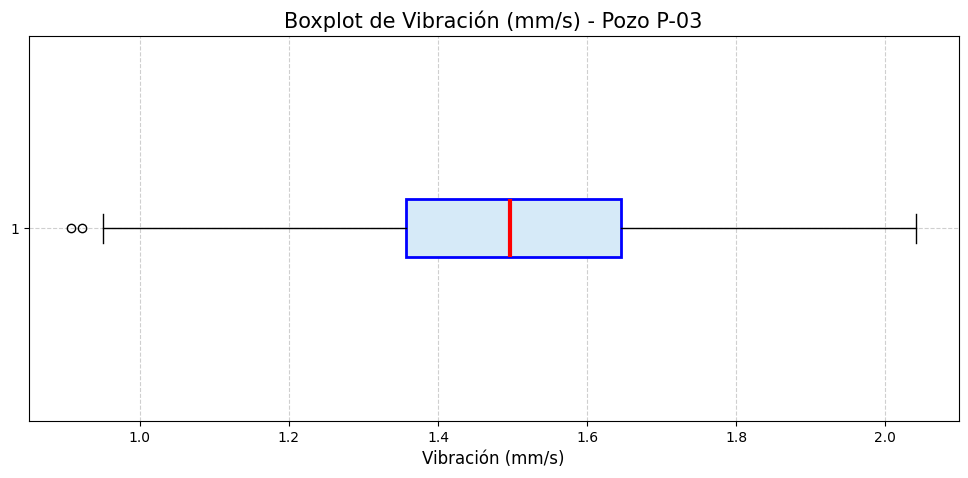

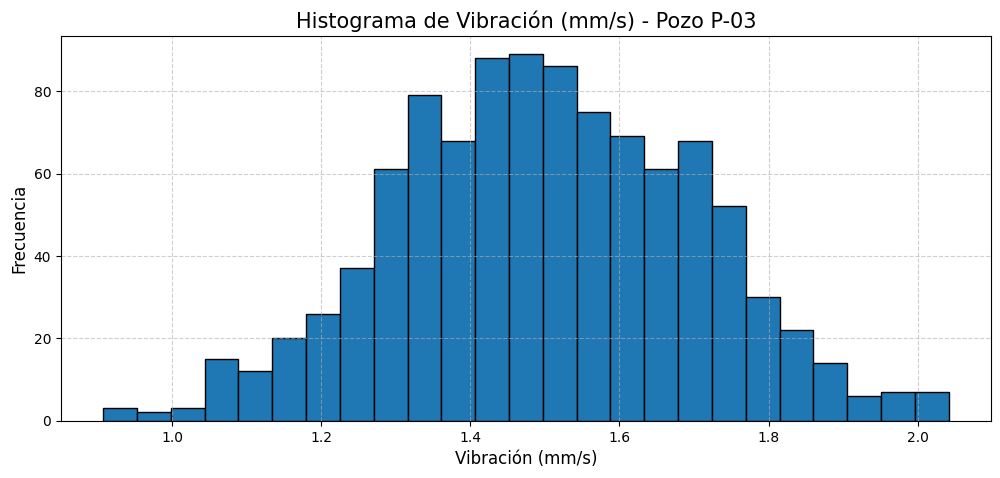

In [331]:
# Analisamos Vibración Pozo 3
analizar_variable(df_limpio, "P-03", "Vibracion_mm_s", "Vibración (mm/s)")

# Analisamos Vibración Pozo 3

El Boxplot muestra muy pocos valores atípicos de vibración, ubicados por debajo de 1,0 mm/s. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se observa señales de alarma.

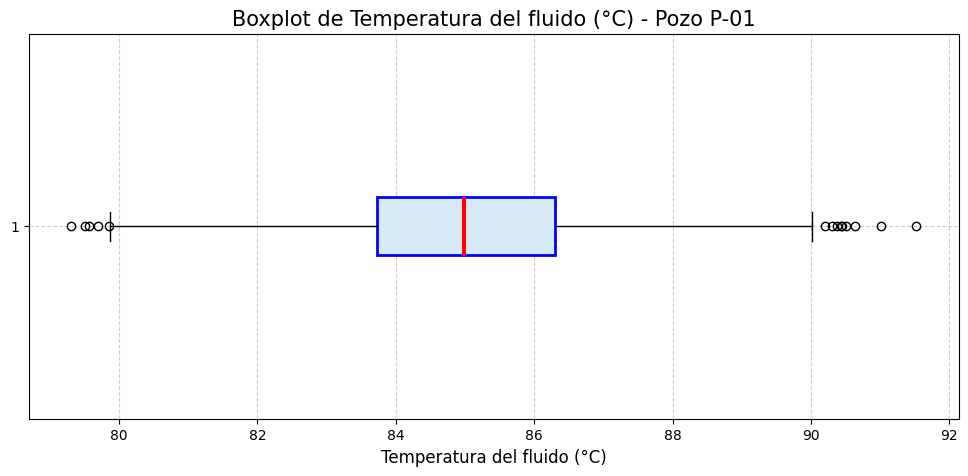

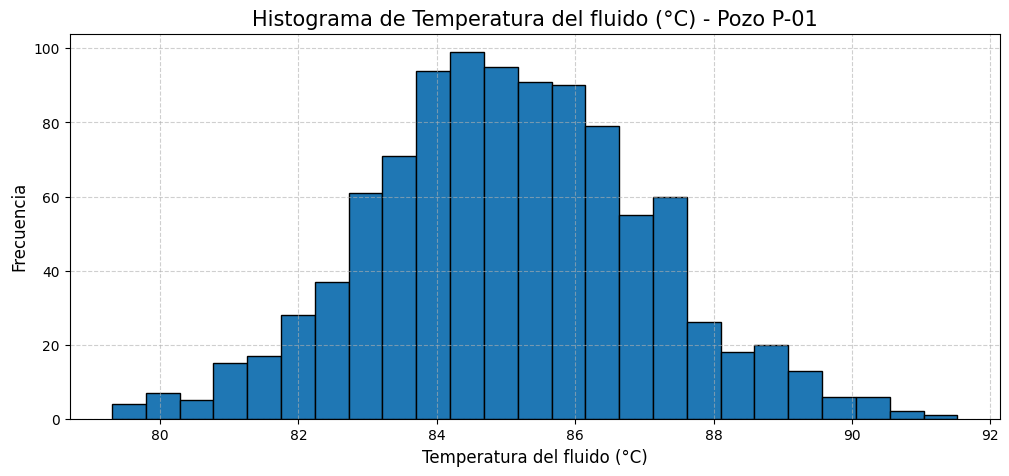

In [332]:
# Analizamos temperatura Pozo 1
analizar_variable(df_limpio, "P-01", "Temp_Fluido_C", "Temperatura del fluido (°C)")

# Analisamos Temperatura Pozo 1

El Boxplot muestra algunos valores atípicos de temperatura tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se observa señales de alarma.

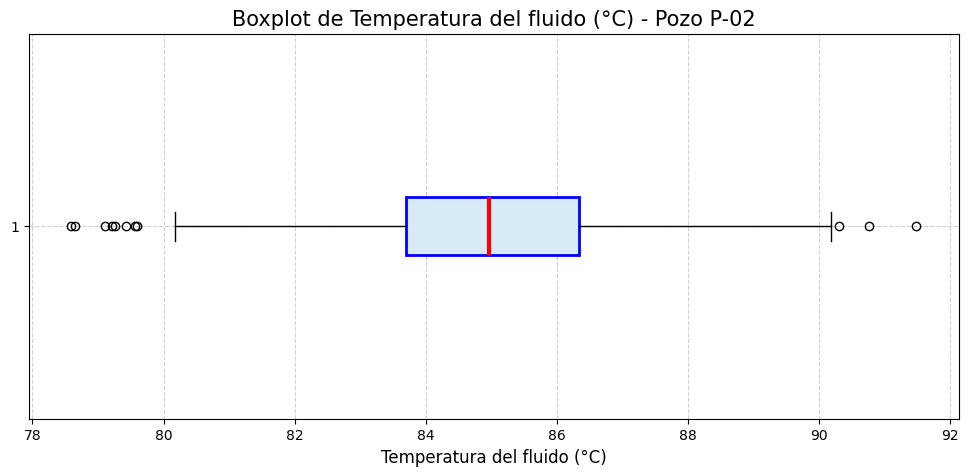

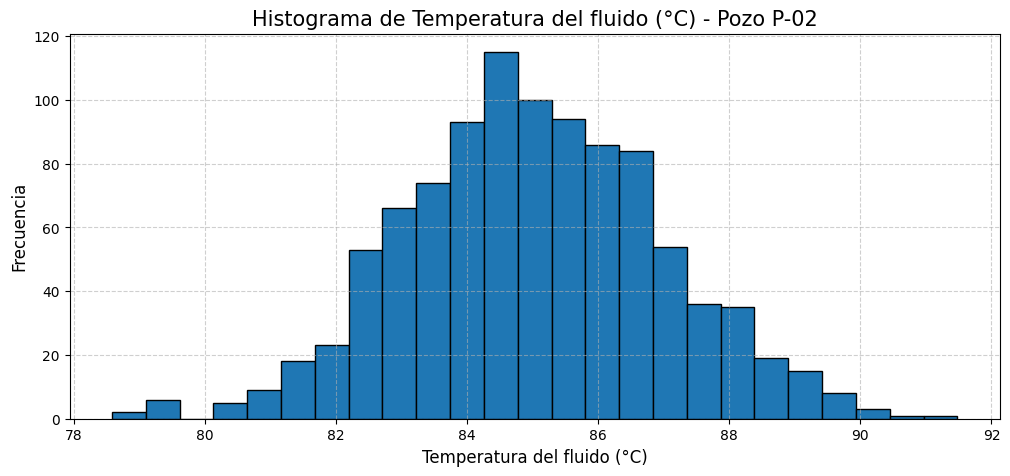

In [333]:
# Analizamos temperatura Pozo 2
analizar_variable(df_limpio, "P-02", "Temp_Fluido_C", "Temperatura del fluido (°C)")

# Analisamos Temperatura Pozo 2

El Boxplot muestra algunos valores atípicos de temperatura tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se observa señales de alarma.

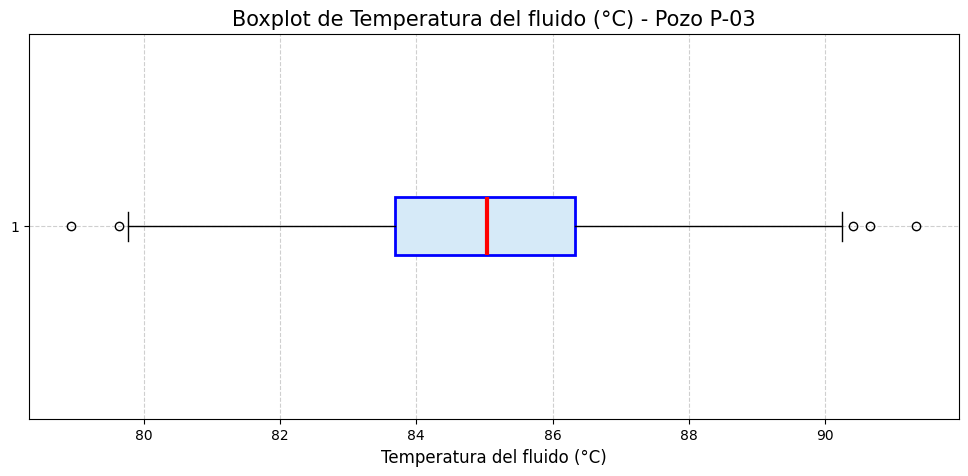

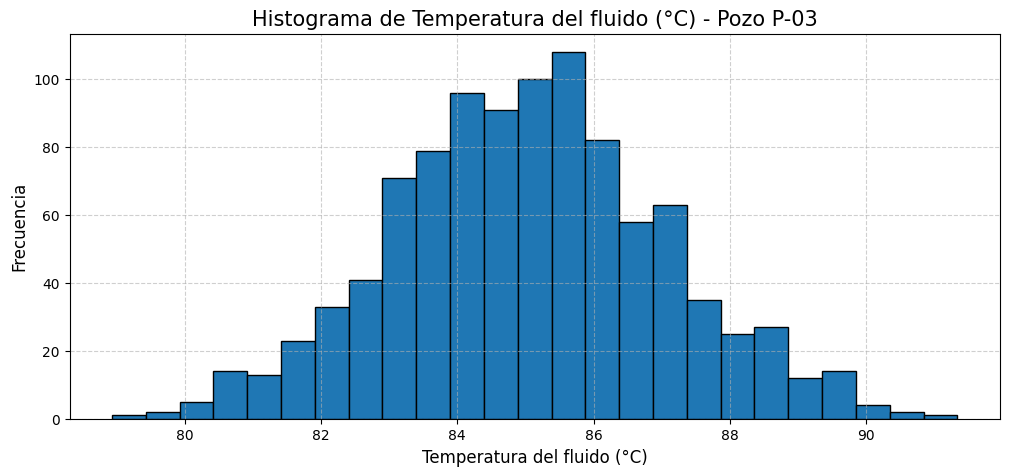

In [334]:
# Analizamos temperatura Pozo 3
analizar_variable(df_limpio, "P-03", "Temp_Fluido_C", "Temperatura del fluido (°C)")

# Analisamos Temperatura Pozo 3

El Boxplot muestra pocos valores atípicos de temperatura, tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se obserba señales de alarma.

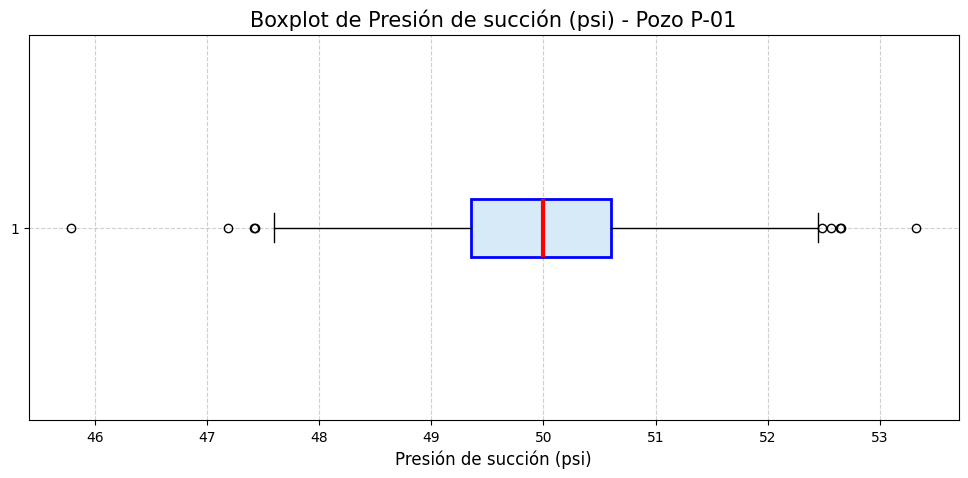

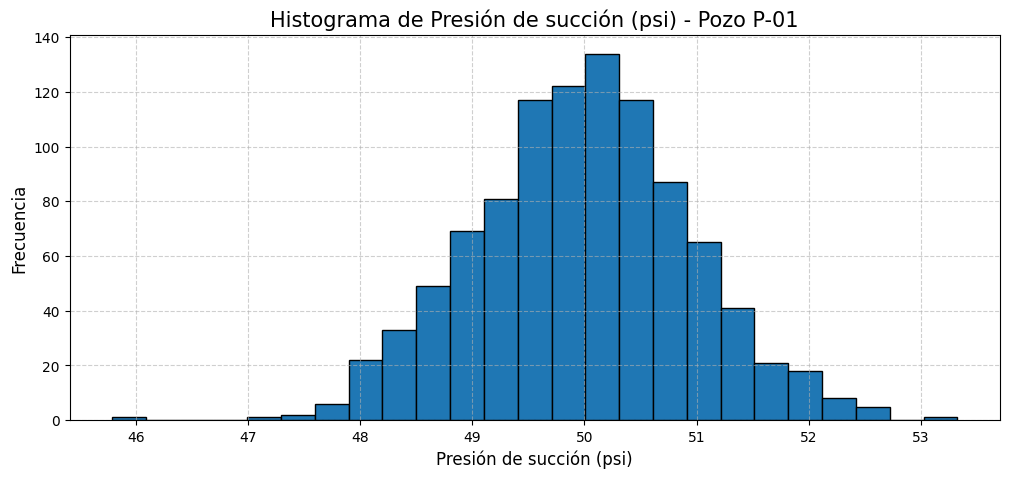

In [335]:
# Analisamos Presión de succión Pozo 1
analizar_variable(df_limpio, "P-01", "Presion_Succion_psi", "Presión de succión (psi)")

# Analisamos Presión de succión Pozo 1

El Boxplot muestra pocos valores atípicos de presión, tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se obserba señales de alarma.

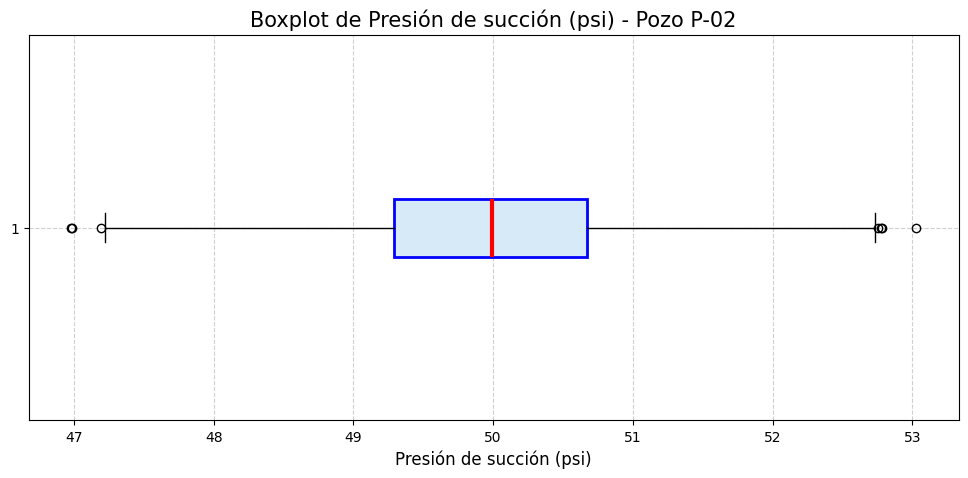

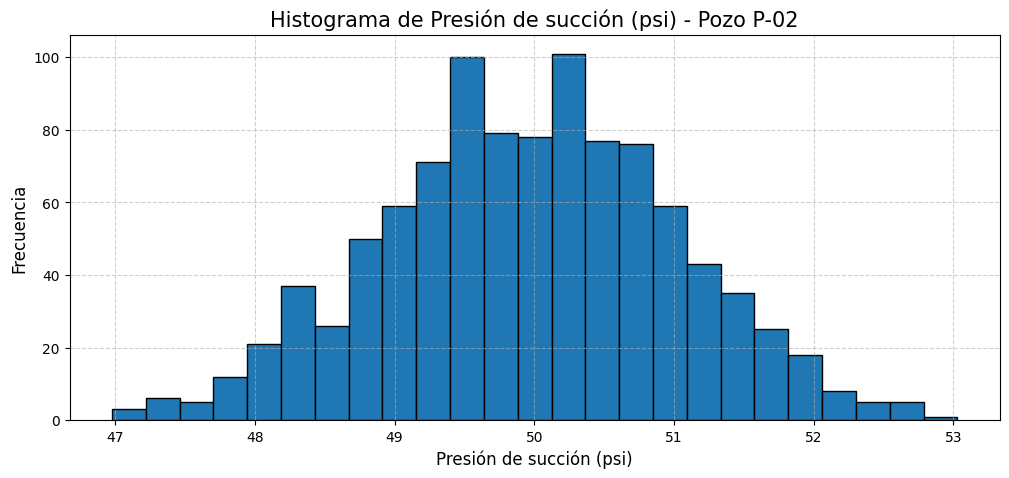

In [336]:
# Analisamos Presión de succión Pozo 2
analizar_variable(df_limpio, "P-02", "Presion_Succion_psi", "Presión de succión (psi)")

# Analisamos Presión de succión Pozo 2

El Boxplot muestra muy pocos valores atípicos de presión, tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se obserba señales de alarma.

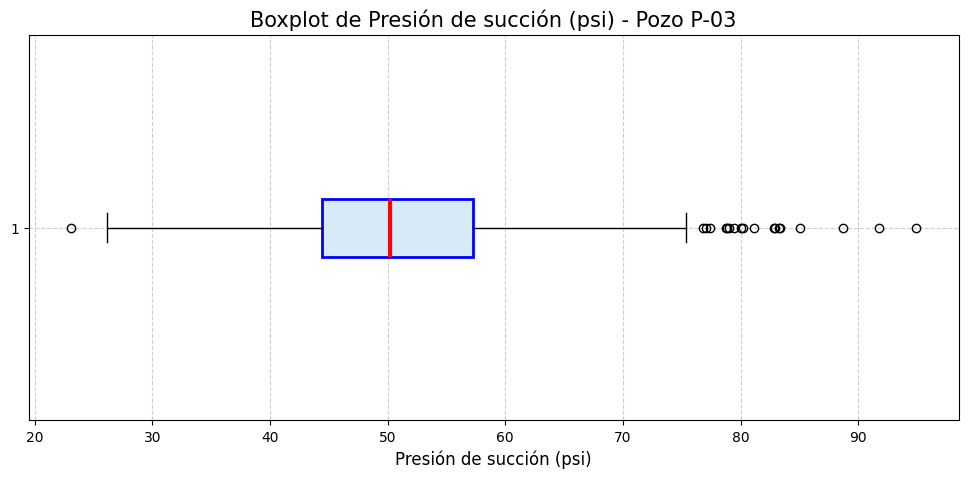

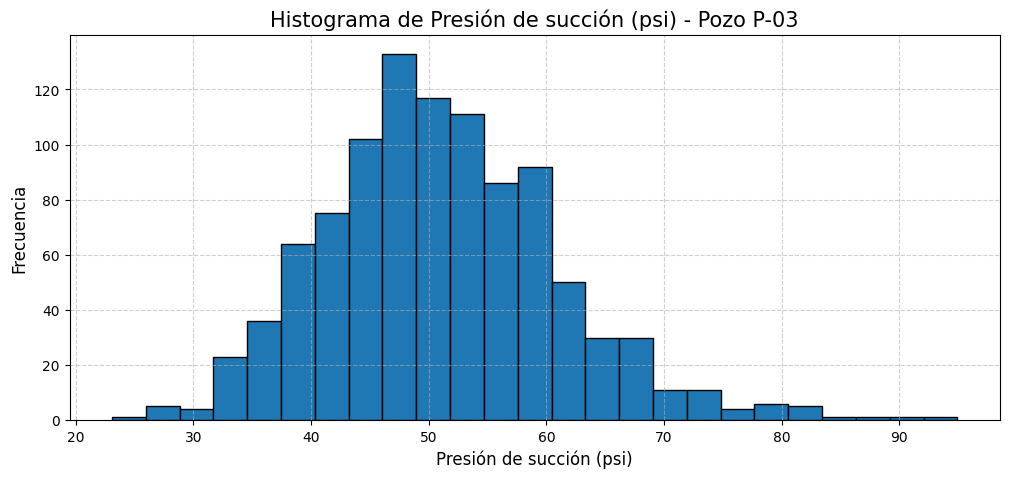

In [337]:
# Analisamos Presión de succión Pozo 3
analizar_variable(df_limpio, "P-03", "Presion_Succion_psi", "Presión de succión (psi)")

# Analisamos Presión de succión Pozo 3

El Boxplot muestra varios valores atípicos de presión, principalmente por encima de 75 psi. El histograma confirma una distribución con una cola extendida hacia valores altos. Esto representa una posible señal de comportamiento anormal en la presión de succión durante la operación.
#¡Se Requiere inspección física inmediata!

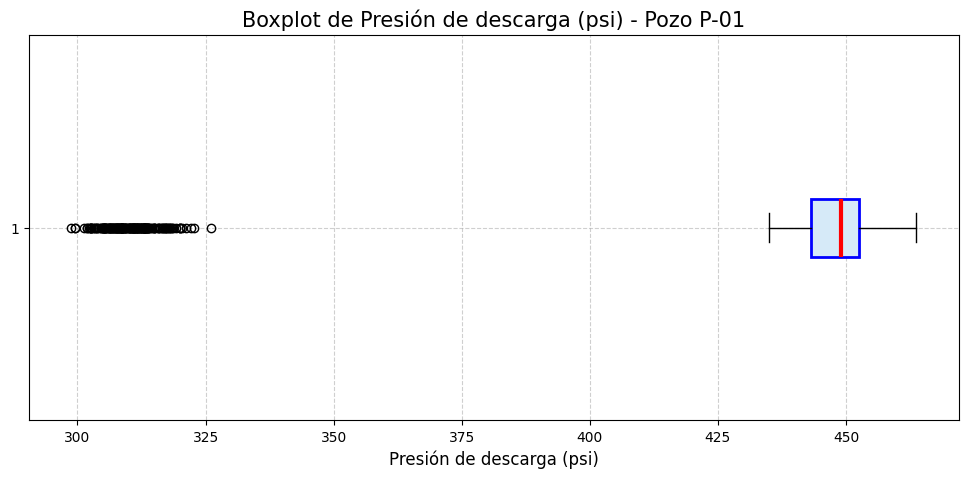

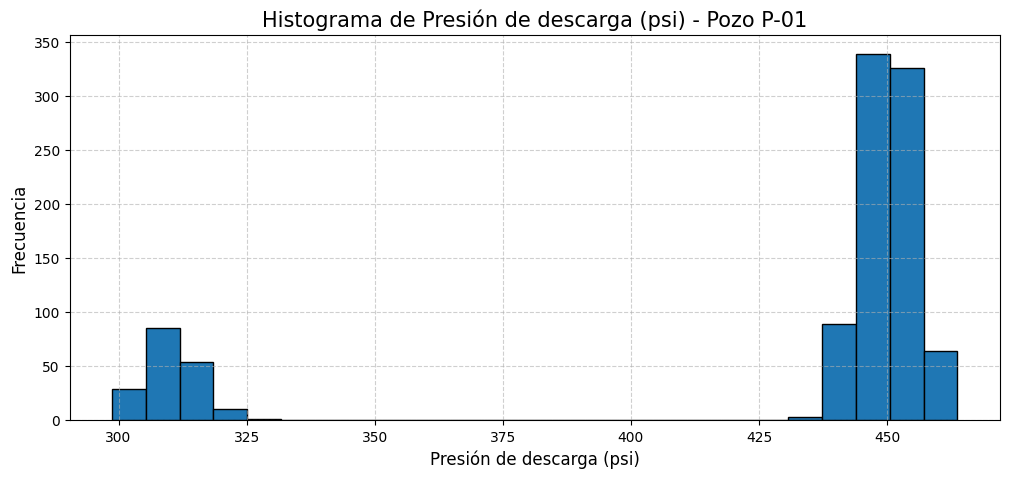

In [338]:
# Analizamos Presión de descarga Pozo 1
analizar_variable(df_limpio, "P-01", "Presion_Descarga_psi", "Presión de descarga (psi)")

# Analizamos Presión de descarga Pozo 1

El Boxplot muestra una gran cantidad de valores atípicos de presión alrededor de 300 a 325 psi. El histograma confirma que estos valores forman un segundo grupo claramente separado de las mediciones principales. Esto representa una señal de comportamiento anormal en la presión de descarga durante una parte de la operación.
# ¡Se Requiere inspección física inmediata!

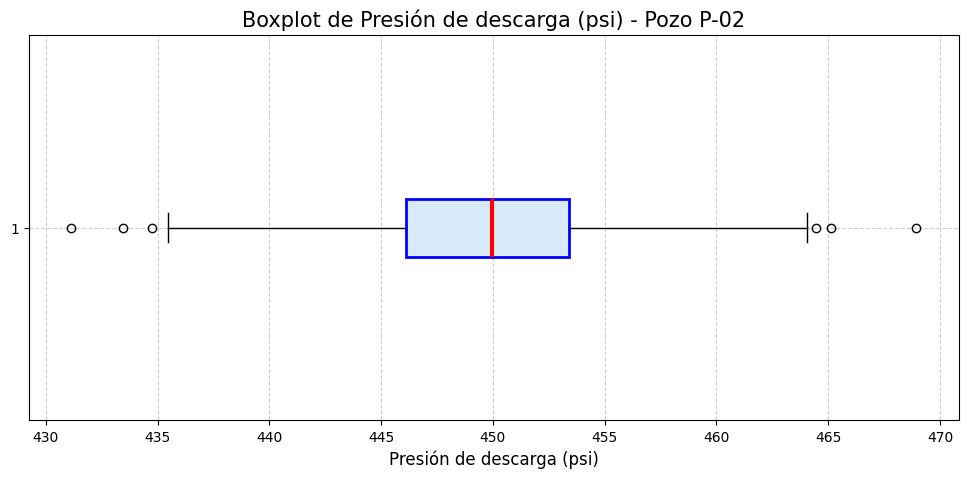

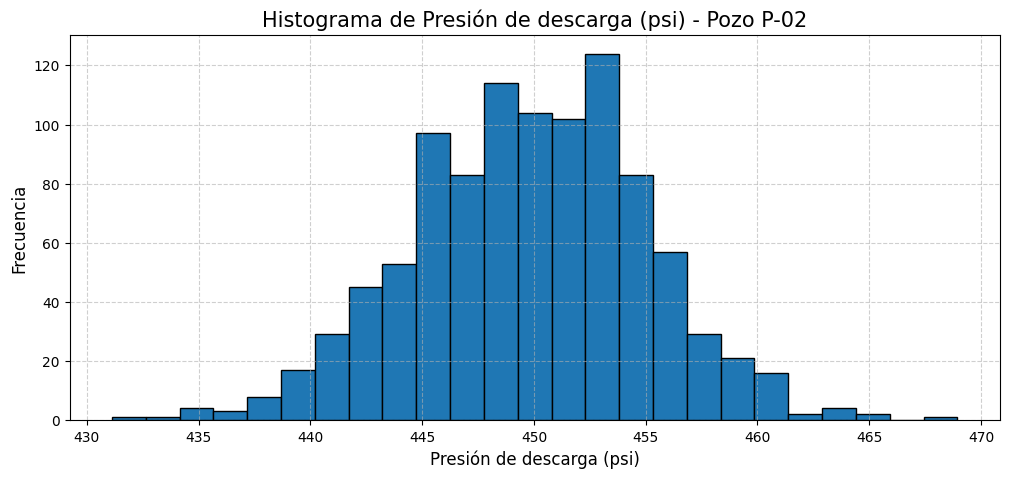

In [339]:
# Analizamos Presión de descarga Pozo 2
analizar_variable(df_limpio, "P-02", "Presion_Descarga_psi", "Presión de descarga (psi)")

# Analizamos Presión de descarga Pozo 2
### Análisis de Presión de Descarga - Pozo P-02

El Boxplot muestra pocos valores atípicos de presión, tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales.
# No se obserba señales de alarma

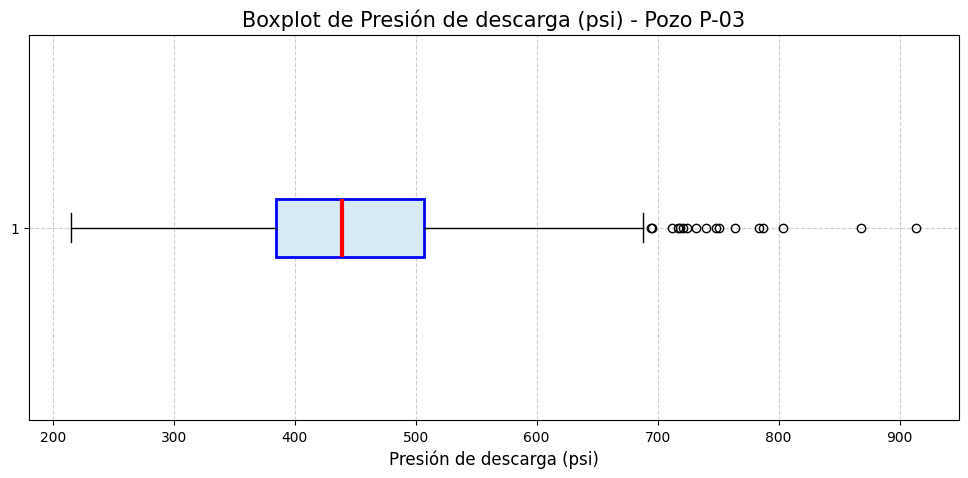

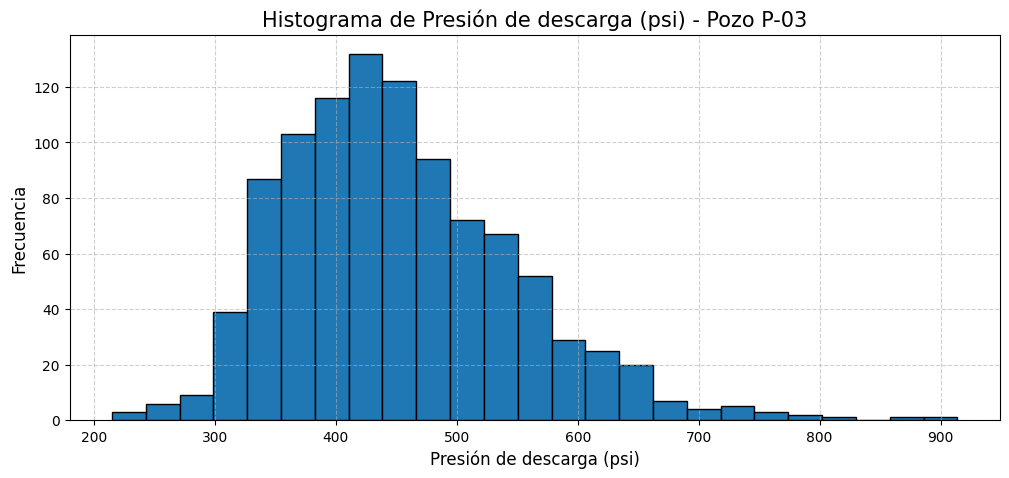

In [340]:
# Analizamos Presión de descarga Pozo 3
analizar_variable(df_limpio, "P-03", "Presion_Descarga_psi", "Presión de descarga (psi)")

# Analizamos Presión de descarga Pozo 3

El Boxplot muestra varios valores atípicos de presión por encima de 700 psi. El histograma confirma una distribución con una cola extendida hacia valores altos. Esto representa una posible señal de comportamiento anormal en la presión de descarga durante la operación.
# ¡Se Requiere inspección física inmediata!

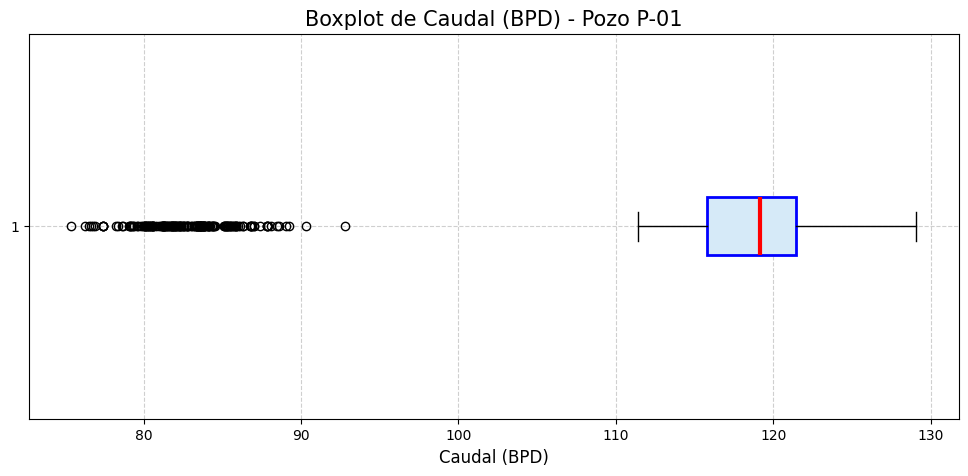

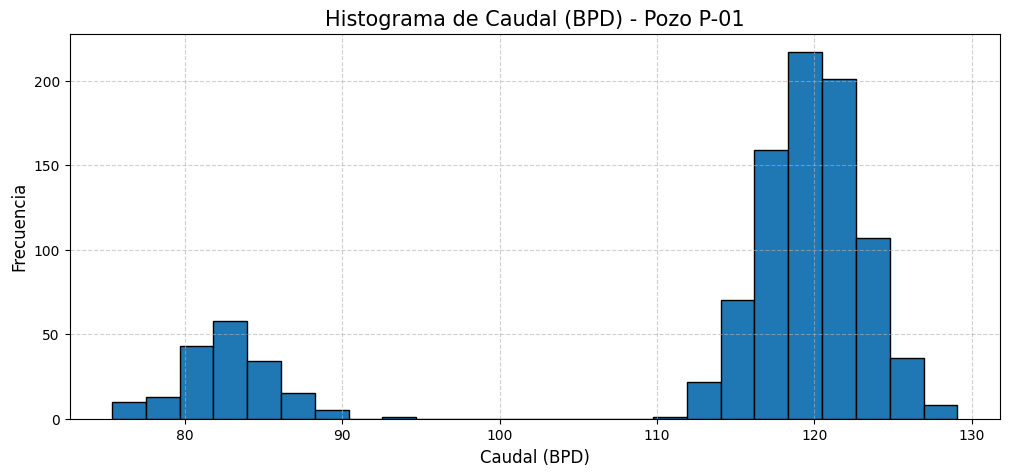

In [341]:
# Analizamos Caudal Pozo 1
analizar_variable(df_limpio, "P-01", "Caudal_BPD", "Caudal (BPD)")

# Analizamos Caudal Pozo 1

El Boxplot muestra una gran cantidad de valores atípicos de caudal por debajo de 90 BPD. El histograma confirma que estos valores forman un segundo grupo claramente separado de las mediciones principales. Esto representa una posible señal de comportamiento anormal del caudal durante una parte de la operación.
# ¡Se Requiere inspección física inmediata!

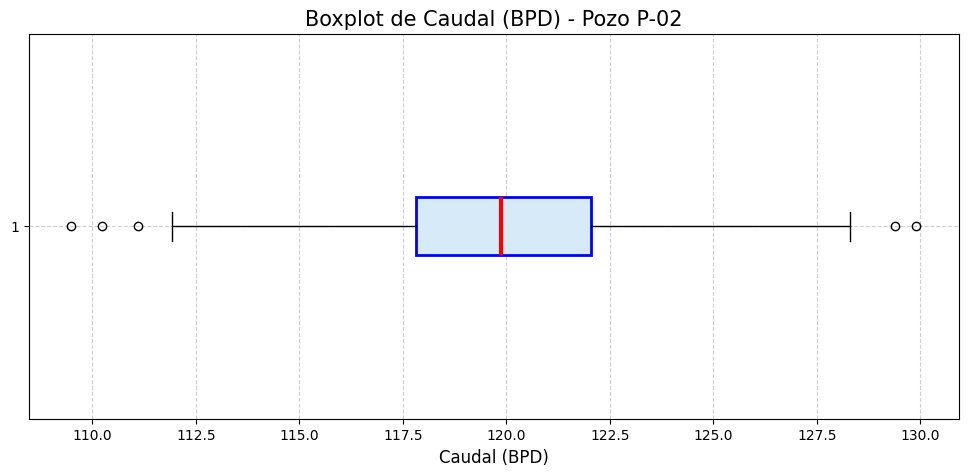

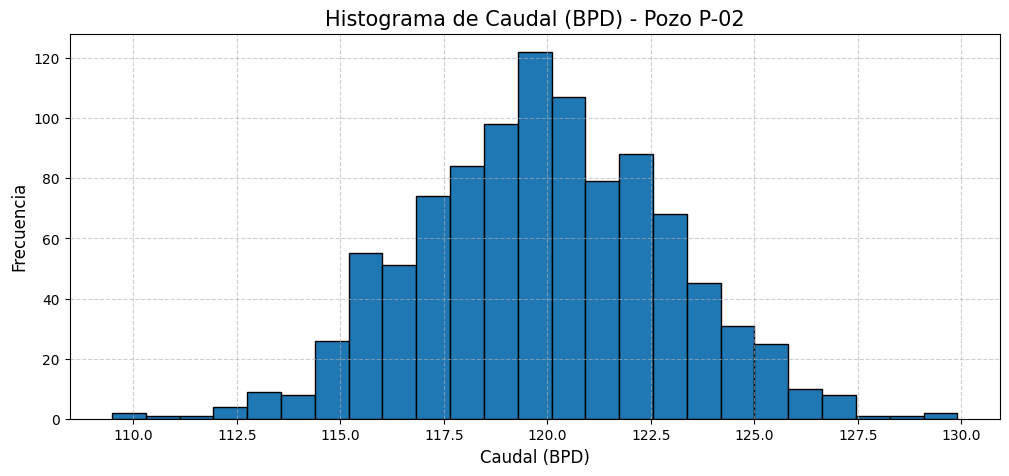

In [342]:
# Analizamos Caudal Pozo 2
analizar_variable(df_limpio, "P-02", "Caudal_BPD", "Caudal (BPD)")

# Analizamos Caudal Pozo 2

El Boxplot muestra pocos valores atípicos de caudal. El histograma presenta una distribución concentrada y sin grupos anormales.
#No se obserba señales de alarma

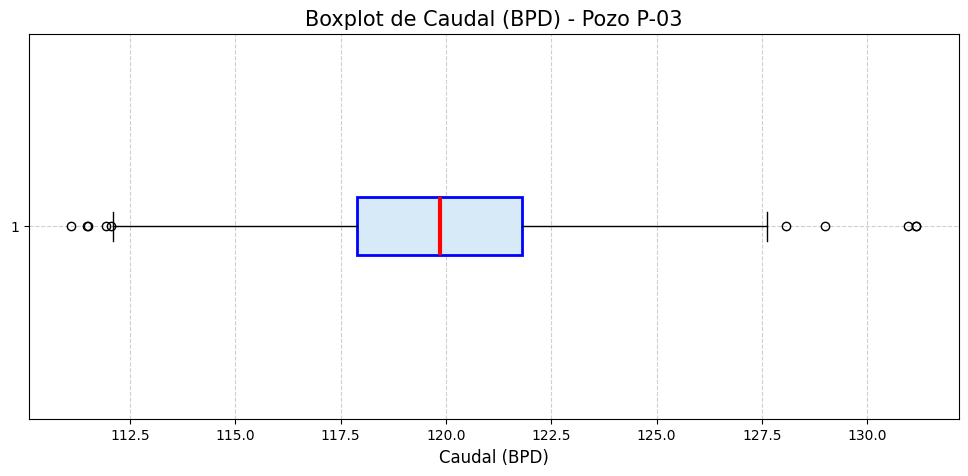

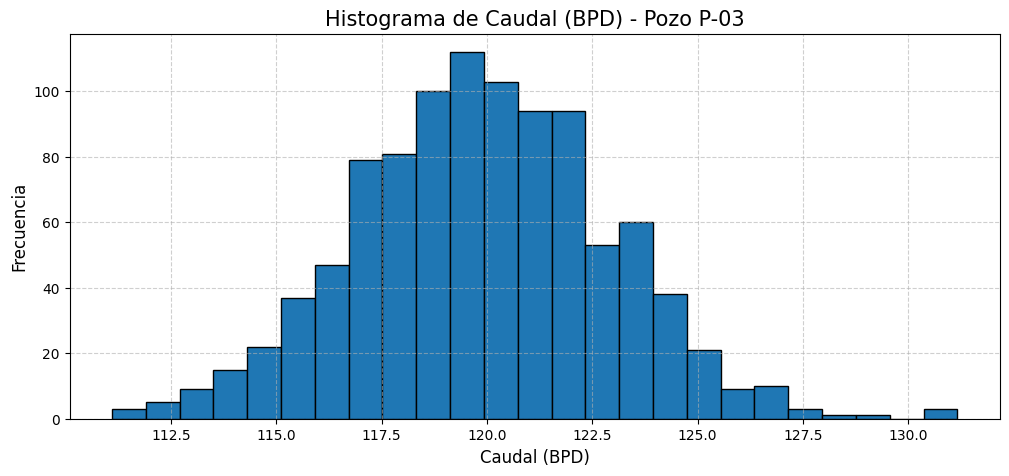

In [343]:
# Analizamos Caudal Pozo 3
analizar_variable(df_limpio, "P-03", "Caudal_BPD", "Caudal (BPD)")

# Analizamos Caudal Pozo 3

El Boxplot muestra pocos valores atípicos de caudal, tanto bajos como altos. El histograma presenta una distribución concentrada y sin grupos anormales separados.
# No se obserba señales de alarma

# Estadísticas Descriptivas

In [344]:
# Se utiliza una funcion para calcular el caudal de los pozos

def calcular_caudal_pozos(df_limpio):
    suma_p01 = 0
    suma_p02 = 0
    suma_p03 = 0

    i = 0
    total_filas = len(df_limpio)

    while i < total_filas:
        if df_limpio.loc[i, "ID_Pozo"] == 'P-01':
            suma_p01 = suma_p01 + df_limpio.loc[i, "Caudal_BPD"]

        elif df_limpio.loc[i, "ID_Pozo"] == 'P-02':
            suma_p02 = suma_p02 + df_limpio.loc[i, "Caudal_BPD"]

        elif df_limpio.loc[i, "ID_Pozo"] == 'P-03':
            suma_p03 = suma_p03 + df_limpio.loc[i, "Caudal_BPD"]

        i = i + 1

    return suma_p01, suma_p02, suma_p03
caudal_p01, caudal_p02, caudal_p03 = calcular_caudal_pozos(df_limpio)

print("Caudal acumulado P-01:", round(caudal_p01, 2), "Barriles")
print("Caudal acumulado P-02:", round(caudal_p02, 2), "Bariiles")
print("Caudal acumulado P-03:", round(caudal_p03, 2), "barriles")

Caudal acumulado P-01: 113269.9 Barriles
Caudal acumulado P-02: 119891.85 Bariiles
Caudal acumulado P-03: 119890.54 barriles


# Ya se calculo el caudal de barriles en el periodo establecido. sabiendo que un barril contiene 158.98 litros calcularemos el volumen total producido por cada pozo.

In [345]:
# Volumen total producido
un_barril_en_litros = 158.98
pozo1_en_litros = caudal_p01 * un_barril_en_litros
pozo2_en_litros = caudal_p02 * un_barril_en_litros
pozo3_en_litros = caudal_p03 * un_barril_en_litros
print("Volumen total producido")
print("Volumen del pozo 1:", round(pozo1_en_litros, 2), "litros")
print("Volumen del pozo 2:", round(pozo2_en_litros, 2), "litros")
print("Volumen del pozo 3:", round(pozo3_en_litros, 2), "litros")


Volumen total producido
Volumen del pozo 1: 18007648.87 litros
Volumen del pozo 2: 19060405.72 litros
Volumen del pozo 3: 19060198.46 litros


In [346]:
# Calculamos la media y la mediana de las vibraciones de cada pozo

vibraciones = df_limpio.groupby("ID_Pozo")["Vibracion_mm_s"].agg(Media = "mean", Mediana="median")

print("Media y mediana de vibraciones por pozo:")
print(vibraciones)

Media y mediana de vibraciones por pozo:
            Media   Mediana
ID_Pozo                    
P-01     1.852108  1.547666
P-02     1.498302  1.497642
P-03     1.500453  1.495963


# El pozo 1 presenta una media más elevada a su promedio, lo que indica una alta vibración mientras que los pozos 2 y 3 tuvieron un comportamiento estable.
# El pozo 1 funciono habitualmente cerca de 1.55 mm/s pero tuvo momentos de vibración severa que arrastro el promedio hacia arriba.
# **¡Se Requiere inspección física inmediata!**


In [347]:
# Se estudia las presiones.

stats_succion = df_limpio.groupby("ID_Pozo")["Presion_Succion_psi"].agg(Media="mean", Mediana="median", Varianza="var", Asimetria_Skew = "skew")
stats_descarga = df_limpio.groupby("ID_Pozo")["Presion_Descarga_psi"].agg(Media="mean", Mediana="median",Varianza="var", Asimetria_Skew = "skew")

print(" PRESIÓN DE SUCCIÓN (psi)")
print(stats_succion)
print(" PRESIÓN DE DESCARGA (psi)")
print(stats_descarga)

 PRESIÓN DE SUCCIÓN (psi)
             Media    Mediana   Varianza  Asimetria_Skew
ID_Pozo                                                 
P-01     49.983368  49.999435   0.907834       -0.034173
P-02     49.963146  49.991876   1.084151       -0.039899
P-03     51.060665  50.238260  99.678865        0.569020
 PRESIÓN DE DESCARGA (psi)
              Media     Mediana     Varianza  Asimetria_Skew
ID_Pozo                                                     
P-01     425.165359  449.079879  2900.844365       -1.656210
P-02     449.806970  449.953670    26.977121       -0.077911
P-03     452.208562  439.289830  9117.135300        0.786897


# ¿ Todos los pozos tienen una dispersión (varianza) similar en sus datos? ¿Qué ocurre con la simetría de los mismos (“skew”)?
#**Análisis de la dispersión (Varianza):**
#**Presión de Succión:**
 El pozo 1 tiene una varianza de 0.91 y el pozo 2 de 1.08 por lo que son muy estables. En cambio, el pozo 3 tiene una varianza de 99.68, casi 100 veces mayor, mostrando gran inestabilidad.
#**Presión de Descarga:**
 El pozo 2 tiene una varianza de 26.98 y se mantiene sumamente constante. el pozo 1 indica 2900.84, que representa alta variación y el pozo 3 con 9117.14 exhibe una dispersión gigantesca.

#**Análisis de la Simetría (Skew)**

 El pozo 2 presenta una distribución simétrica porque tiene un skew cercano a cero tanto en succión (-0.04) como en descarga (-0.08).
 El pozo 1 presenta una succión simetría (-0.03), pero su descarga tiene un Skew de (-1.66) (sesgo a la izquierda). lo que podría indicar momentos de baja presión.
 El pozo 3 muestra un Skew positivo tanto en succión (+0.57) como en descarga (+0.79) (sesgo a la derecha).
 lo que podría indicar momentos de alta presión.
